In [73]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage
import statsmodels.api as sm
import rasterio
import PIL.Image
from tqdm import tqdm

In [2]:
DIRECTORY = pathlib.Path("~/storage/data/oaec-found-gully").expanduser()

In [3]:
PIL.Image.MAX_IMAGE_PIXELS = None  # I know my images are large; they're not DoS attacks...

In [4]:
names = {
    "pepperwood": "Big Pepperwood Creek",
    "dutch": "Dutch Bill Creek",
    "flat": "Flat Ridge Creek Buckeye",
    "kolmer": "Kolmer Gulch",
    "drylow": "Lower Dry Creek Lower",
    "dry": "Lower Dry Creek",
    "salmon": "Lower Salmon Creek",
    "tombs": "Tombs Creek",
    "sulphur": "Upper Big Sulphur Creek",
}

truth = []
metrics = {
    "min15": [],
    "max15": [],
    "low15": [],
    "highlow15": [],
    "min5": [],
    "max5": [],
    "low5": [],
    "highlow5": [],
}

for name in tqdm(names):
    with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-mask.png") as file:
        mask = np.asarray(file)[:, :, 1] < 128

    with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-gully.png") as file:
        gully = np.asarray(file)[:, :, 1] > 128

    for metric in metrics:
        with rasterio.open(DIRECTORY / "derived" / metric / f"{names[name]}-{metric}.tif") as file:
            data = file.read(1)
        np.logical_and(mask, ~np.isnan(data), out=mask)  # assumes they all have NaNs in the same places
        metrics[metric].append(data[mask])
        del data

    truth.append(gully[mask])
    del mask
    del gully

100%|█████████████████████████████████████████████████████████████████| 9/9 [01:29<00:00,  9.96s/it]


In [5]:
slices = []
start = 0
for name, array in zip(names, truth):
    stop = start + len(array)
    slices.append(slice(start, stop))
    start = stop

alltruth = np.concatenate(truth)
allmetrics = {metric: np.concatenate(arrays) for metric, arrays in metrics.items()}

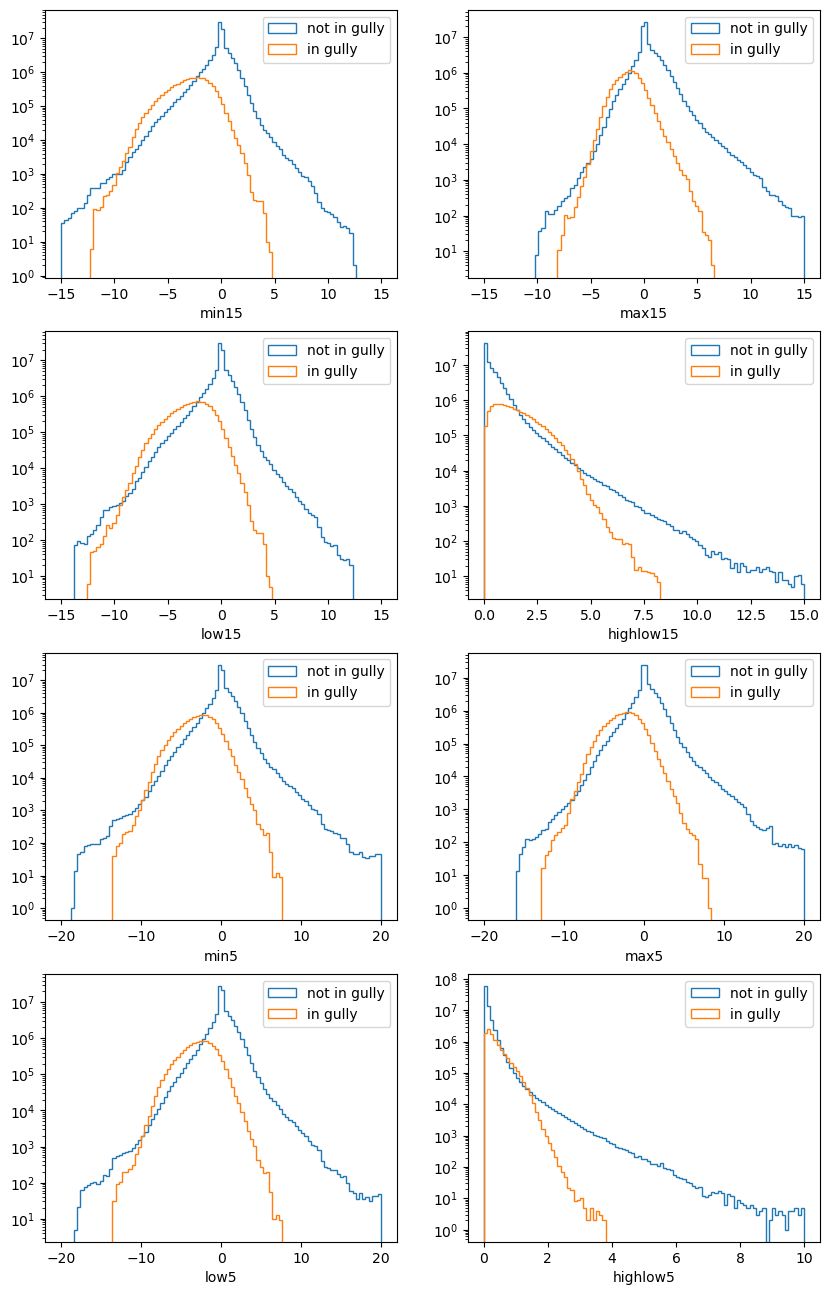

In [6]:
fig, axs = plt.subplots(4, 2, figsize=(10, 16))

ranges = {
    "min15": (-15, 15),
    "max15": (-15, 15),
    "low15": (-15, 15),
    "highlow15": (0, 15),
    "min5": (-20, 20),
    "max5": (-20, 20),
    "low5": (-20, 20),
    "highlow5": (0, 10),
}

for ax, metric in zip(axs.flatten(), metrics):
    ax.hist(allmetrics[metric][~alltruth], bins=100, range=ranges[metric], histtype="step", label="not in gully")
    ax.hist(allmetrics[metric][alltruth], bins=100, range=ranges[metric], histtype="step", label="in gully")

    ax.legend()
    
    ax.set_yscale("log")
    ax.set_xlabel(metric)

None

In [7]:
del truth
del metrics

features = [
    "min15",
    "max15",
    "low15",
    "highlow15",
    "min5",
    "max5",
    "low5",
    # "highlow5",
    "low15 * highlow15",
    "low15 * highlow5",
    "low5 * highlow15",
    "low5 * highlow5",
]

X = np.stack([
    allmetrics["min15"],
    allmetrics["max15"],
    allmetrics["low15"],
    allmetrics["highlow15"],
    allmetrics["min5"],
    allmetrics["max5"],
    allmetrics["low5"],
    # allmetrics["highlow5"],
    allmetrics["low15"] * allmetrics["highlow15"],
    allmetrics["low15"] * allmetrics["highlow5"],
    allmetrics["low5"] * allmetrics["highlow15"],
    allmetrics["low5"] * allmetrics["highlow5"],
]).T
Y = alltruth

del allmetrics
del alltruth

In [22]:
fit = sm.Logit(Y, sm.add_constant(X)).fit()

Optimization terminated successfully.
         Current function value: 0.170158
         Iterations 8


In [23]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:             93752708
Model:                          Logit   Df Residuals:                 93752696
Method:                           MLE   Df Model:                           11
Date:                Tue, 07 Oct 2025   Pseudo R-squ.:                  0.5000
Time:                        16:18:25   Log-Likelihood:            -1.5953e+07
converged:                       True   LL-Null:                   -3.1904e+07
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.6080      0.001  -4141.918      0.000      -4.610      -4.606
x1            -2.5578      0.006   -455.240      0.000      -2.569      -2.547
x2            -1.4481      0.007   -217.705      0.000      -1.461      -1.435
x3            -1.0344      0.007   -153.923      0.000      -1.048      -1.021
x4             2.1673      0.006    346.592      0.000       2.155       2.180
x5             0.1465      0.018      8.006      0.000       0.111       0.182
x6             0.3549      0.005     66.833      0.000       0.344       0.365
x7             2.4436      0.019    129.598      0.000       2.407       2.481
x8             1.6547      0.002    785.104      0.000       1.651       1.659
x9            -0.5225      0.005   -110.016      0.000      -0.532      -0.513
x10           -1.1423      0.002   -604.962      0.000      -1.146      -1.139
x11            0.4982      0.004    136.223      0.000       0.491       0.505
==============================================================================
"""

In [25]:
fit.params

array([-4.60797027, -2.55777966, -1.4481302 , -1.03443282,  2.16730996,
        0.14654325,  0.35490593,  2.44362265,  1.6547355 , -0.52254432,
       -1.14226887,  0.49822636])

In [49]:
for feature, parameter in zip(["(intercept)"] + features, fit.params):
    print(f"{feature:25s} {parameter:9.6f}")

(intercept)               -4.607970
min15                     -2.557780
max15                     -1.448130
low15                     -1.034433
highlow15                  2.167310
min5                       0.146543
max5                       0.354906
low5                       2.443623
low15 * highlow15          1.654735
low15 * highlow5          -0.522544
low5 * highlow15          -1.142269
low5 * highlow5            0.498226


In [78]:
cov_mat = fit.cov_params()
stdev = np.sqrt(np.diag(cov_mat))
corr_mat = cov_mat / np.outer(stdev, stdev)

pd.DataFrame(corr_mat, index=["(intercept)"] + features, columns=["(intercept)"] + features).style.background_gradient(
    cmap="coolwarm", vmin=-1, vmax=1
)

,(intercept),min15,max15,low15,highlow15,min5,max5,low5,low15 * highlow15,low15 * highlow5,low5 * highlow15,low5 * highlow5
(intercept),1.000000,0.130398,-0.137264,0.240866,0.052696,0.006814,-0.059900,-0.045826,-0.337117,-0.022673,0.285852,0.003477
min15,0.130398,1.000000,-0.448335,-0.395916,0.427867,-0.310307,0.289366,0.216824,-0.042733,0.059095,0.041389,-0.052223
max15,-0.137264,-0.448335,1.000000,-0.522166,-0.946967,0.028896,-0.333913,0.044559,0.062134,-0.123519,-0.052767,0.087575
low15,0.240866,-0.395916,-0.522166,1.000000,0.532556,0.262923,-0.019536,-0.298089,-0.282826,0.058841,0.288513,-0.043743
highlow15,0.052696,0.427867,-0.946967,0.532556,1.000000,0.017112,0.116767,-0.040538,0.069983,-0.013013,-0.039883,0.029044
min5,0.006814,-0.310307,0.028896,0.262923,0.017112,1.000000,-0.084921,-0.957009,-0.019434,0.024606,0.047716,-0.067284
max5,-0.059900,0.289366,-0.333913,-0.019536,0.116767,-0.084921,1.000000,-0.168460,-0.288046,0.649754,0.164769,-0.498861
low5,-0.045826,0.216824,0.044559,-0.298089,-0.040538,-0.957009,-0.168460,1.000000,0.182334,-0.201948,-0.182049,0.206528
low15 * highlow15,-0.337117,-0.042733,0.062134,-0.282826,0.069983,-0.019434,-0.288046,0.182334,1.000000,-0.587559,-0.977093,0.643952
low15 * highlow5,-0.022673,0.059095,-0.123519,0.058841,-0.013013,0.024606,0.649754,-0.201948,-0.587559,1.000000,0.496665,-0.957548


In [55]:
test_samples = np.stack([np.ones(1000)] + [np.random.uniform(-10, 10, 1000) for _ in features]).T

predictions = fit.predict(test_samples)

def logistic(x):
    return 1/(1 + np.exp(-x))

for test_sample, prediction in zip(test_samples, predictions):
    assert logistic(fit.params @ test_sample.T) == prediction

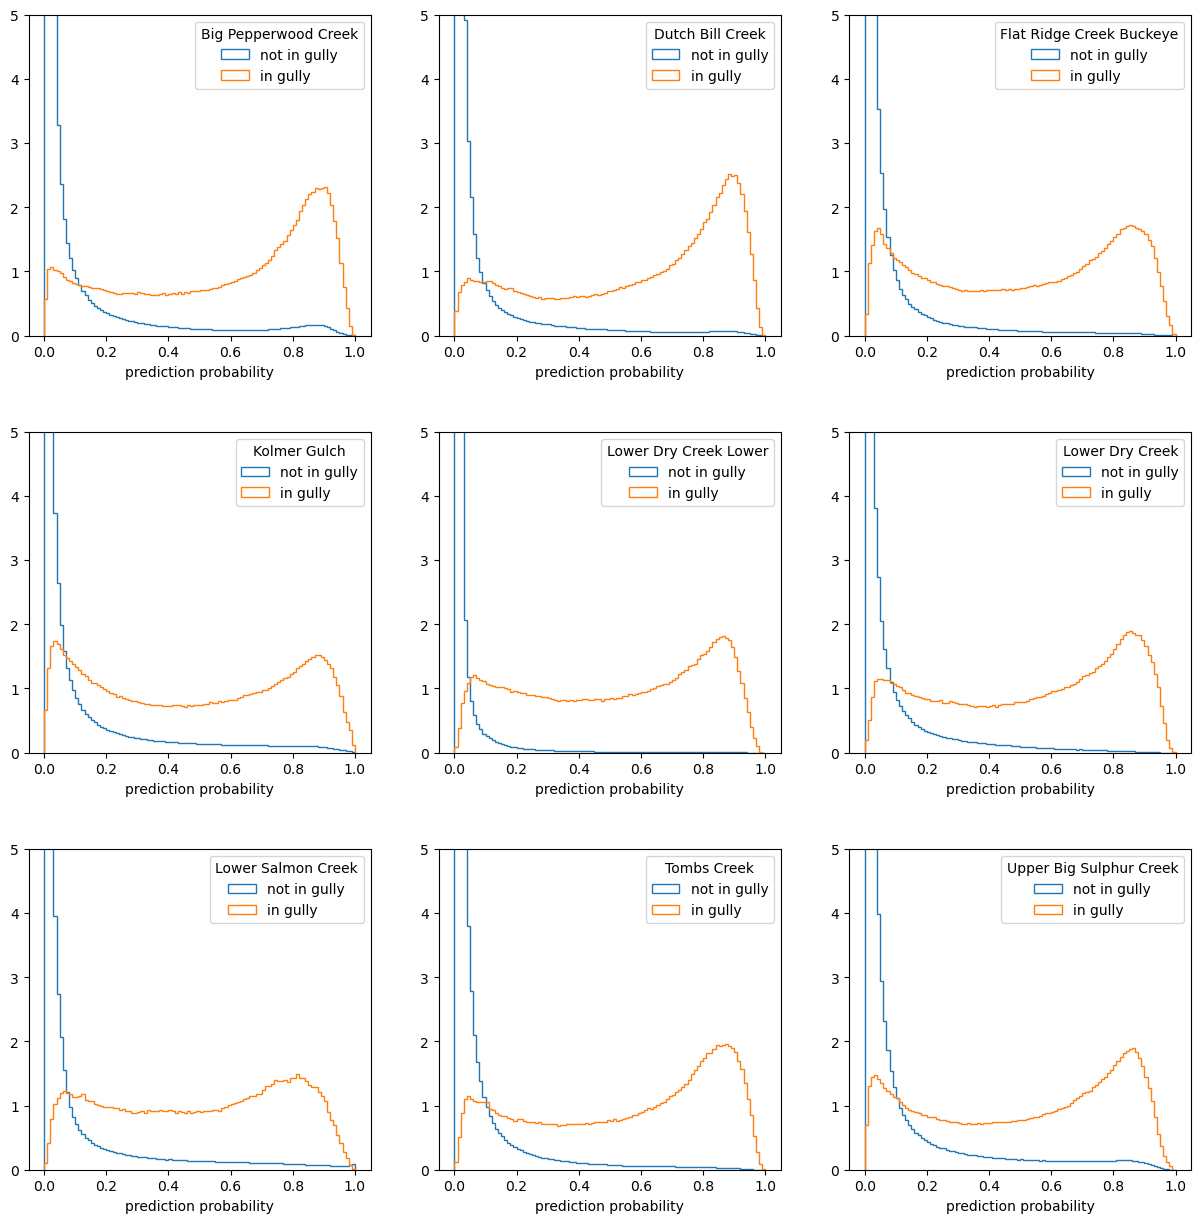

In [57]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for ax, name, slc in zip(axs.flatten(), names, slices):
    ax.hist(fit.predict(sm.add_constant(X)[slc][~Y[slc]]), bins=100, range=(0, 1), density=True, histtype="step", label="not in gully")
    ax.hist(fit.predict(sm.add_constant(X)[slc][Y[slc]]), bins=100, range=(0, 1), density=True, histtype="step", label="in gully")

    ax.legend(loc="upper right", title=names[name])

    ax.set_ylim(0, 5)
    ax.set_xlabel("prediction probability")

plt.subplots_adjust(hspace=0.3)

None

In [ ]:
name = "dutch"

with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-mask.png") as file:
    mask = np.asarray(file)[:, :, 1] < 128

with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-gully.png") as file:
    gully = (np.asarray(file)[:, :, 1] > 128).astype(np.float32)

gully[~mask] = np.nan

metrics = {
    "min15": None,
    "max15": None,
    "low15": None,
    "highlow15": None,
    "min5": None,
    "max5": None,
    "low5": None,
    "highlow5": None,
}
for metric in metrics:
    with rasterio.open(DIRECTORY / "derived" / metric / f"{names[name]}-{metric}.tif") as file:
        data = file.read(1)
    np.logical_and(mask, ~np.isnan(data), out=mask)  # assumes they all have NaNs in the same places
    metrics[metric]= data

X_test = np.stack([
    metrics["min15"],
    metrics["max15"],
    metrics["low15"],
    metrics["highlow15"],
    metrics["min5"],
    metrics["max5"],
    metrics["low5"],
    # metrics["highlow5"],
    metrics["low15"] * metrics["highlow15"],
    metrics["low15"] * metrics["highlow5"],
    metrics["low5"] * metrics["highlow15"],
    metrics["low5"] * metrics["highlow5"],
]).transpose(1, 2, 0)

assert not np.isnan(X_test[mask]).any()
X_test[np.isnan(X_test)] = 0

In [65]:
probability = fit.predict(sm.add_constant(X_test.reshape(-1, len(features)))).reshape(mask.shape)
probability[~mask] = np.nan

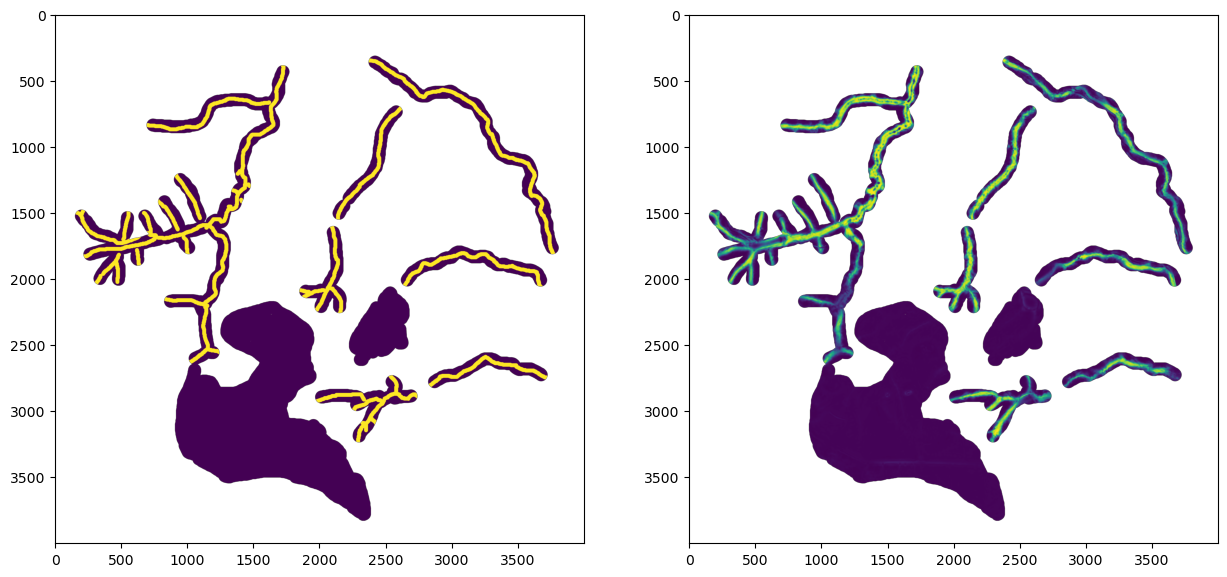

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

ax1.imshow(gully[15000:19000, 14000:18000])
ax2.imshow(probability[15000:19000, 14000:18000])

None